In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (1470, 35)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(0)

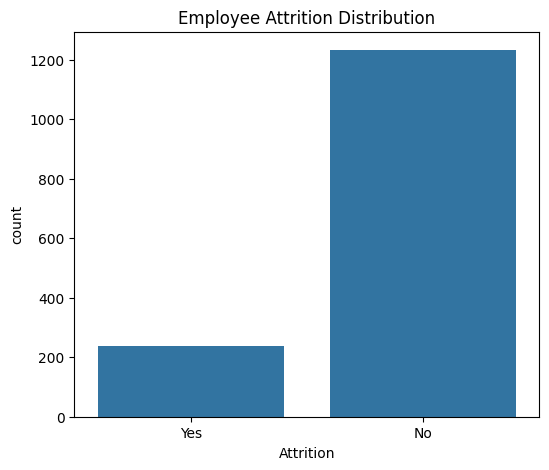

In [11]:
plt.figure(figsize=(6,5))
sns.countplot(x='Attrition', data=df)
plt.title('Employee Attrition Distribution')
plt.show()

In [12]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [13]:
(df['Attrition'].value_counts(normalize=True)*100).round(2)

,proportion
Attrition,
No,83.88
Yes,16.12


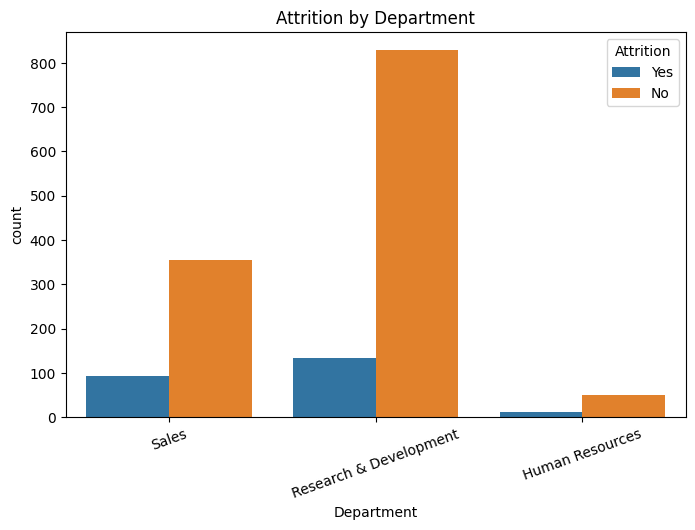

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.xticks(rotation=20)
plt.title('Attrition by Department')
plt.show()

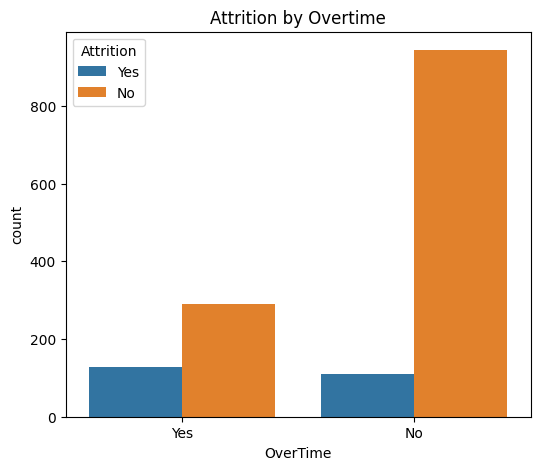

In [15]:
plt.figure(figsize=(6,5))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('Attrition by Overtime')
plt.show()

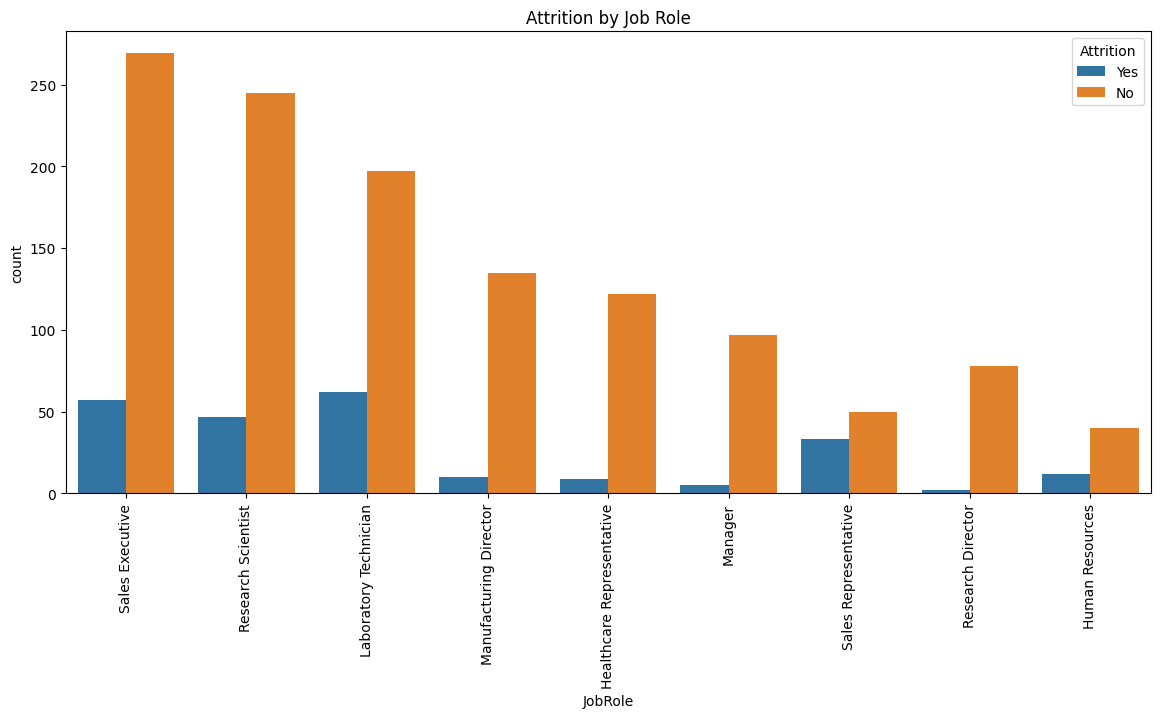

In [16]:
plt.figure(figsize=(14,6))
sns.countplot(x='JobRole', hue='Attrition', data=df)
plt.xticks(rotation=90)
plt.title('Attrition by Job Role')
plt.show()

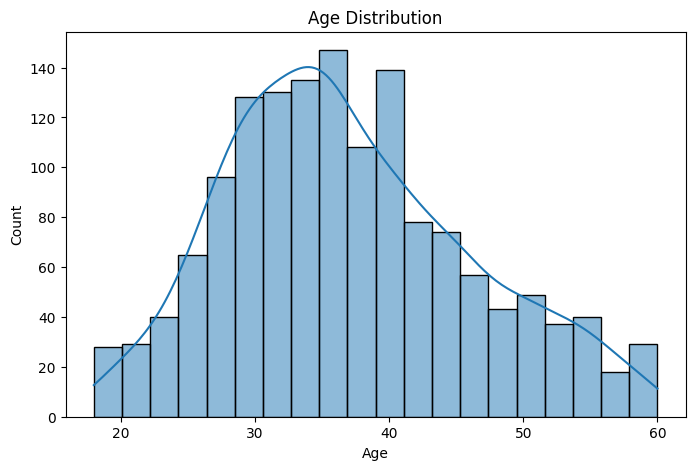

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

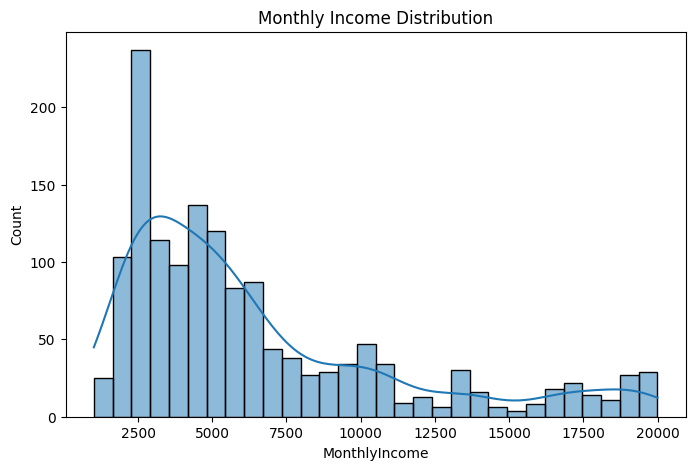

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyIncome'], bins=30, kde=True)
plt.title('Monthly Income Distribution')
plt.show()

In [19]:
numeric_df = df.select_dtypes(include=['int64'])

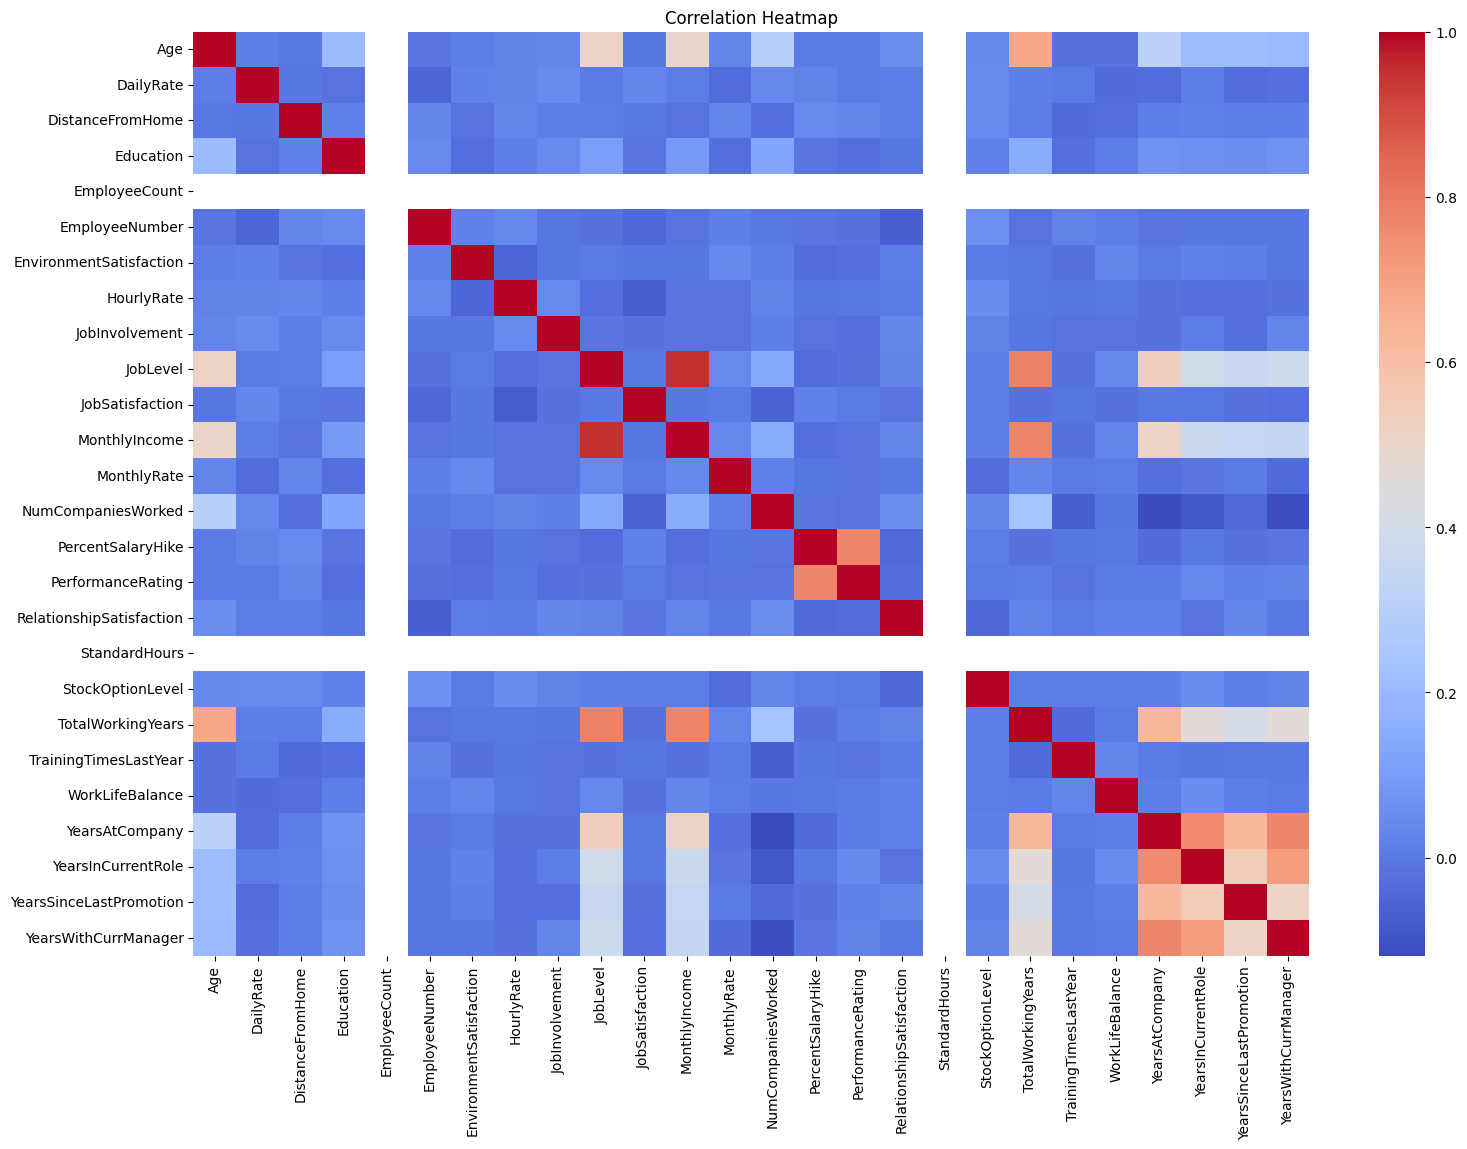

In [20]:
plt.figure(figsize=(18,12))
sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

In [21]:
df['Attrition'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})

In [22]:
df['Attrition'].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [23]:
correlation = df.corr(numeric_only=True)

correlation['Attrition'].sort_values(
    ascending=False
)

,Attrition
Attrition,1.000000
DistanceFromHome,0.077924
NumCompaniesWorked,0.043494
MonthlyRate,0.015170
PerformanceRating,0.002889
HourlyRate,-0.006846
EmployeeNumber,-0.010577
PercentSalaryHike,-0.013478
Education,-0.031373
YearsSinceLastPromotion,-0.033019


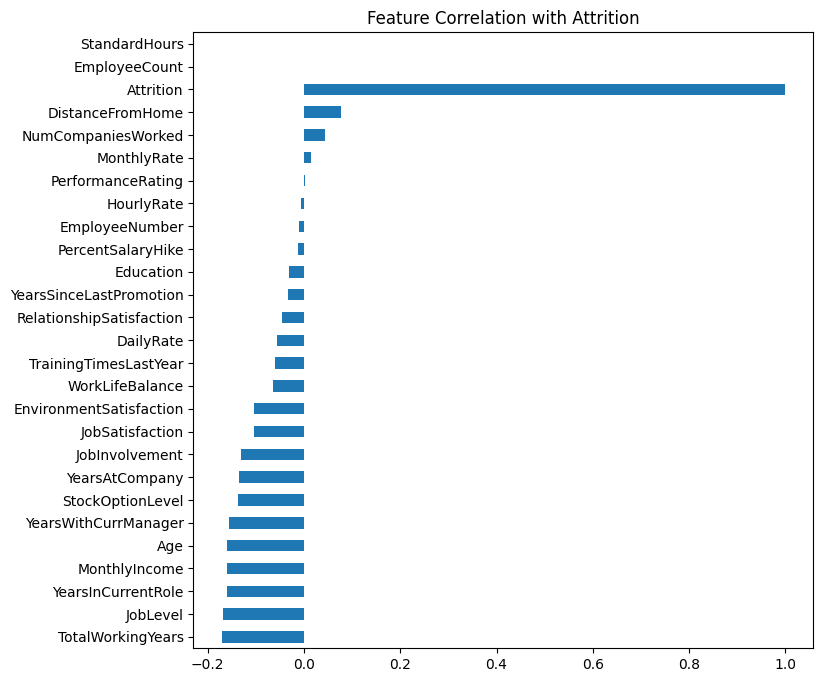

In [24]:
plt.figure(figsize=(8,8))

correlation['Attrition'].sort_values().plot(
    kind='barh'
)

plt.title('Feature Correlation with Attrition')
plt.show()

In [25]:
df.dtypes

,0
Age,int64
Attrition,int64
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [26]:
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [27]:
df.drop(
    columns=[
        'EmployeeCount',
        'EmployeeNumber',
        'Over18',
        'StandardHours'
    ],
    inplace=True
)

In [28]:
df.shape

(1470, 31)

In [29]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [30]:
print(X.shape)
print(y.shape)

(1470, 30)
(1470,)


In [31]:
from sklearn.preprocessing import LabelEncoder

In [32]:
le = LabelEncoder()

In [33]:
cat_cols = X.select_dtypes(include=['object']).columns
cat_cols

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [34]:
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

In [35]:
X.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,2,1102,2,1,2,1,2,0,94,...,3,1,0,8,0,1,6,4,0,5
1,49,1,279,1,8,1,1,3,1,61,...,4,4,1,10,3,3,10,7,1,7
2,37,2,1373,1,2,2,4,4,1,92,...,3,2,0,7,3,3,0,0,0,0
3,33,1,1392,1,3,4,1,4,0,56,...,3,3,0,8,3,3,8,7,3,0
4,27,2,591,1,2,1,3,1,1,40,...,3,4,1,6,3,3,2,2,2,2


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [37]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1176, 30)
X_test : (294, 30)
y_train: (1176,)
y_test : (294,)


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
X_train_scaled[:5]

array([[ 1.09019402,  0.59751994,  1.04945488,  1.38663512, -0.89991452,
         1.06420933, -0.93841037, -0.65870975, -1.22128024, -0.90843647,
         1.79528209,  1.76218896, -0.57421335, -0.64799683, -1.49916852,
         2.02675233,  0.93128918,  1.33076293, -0.63772923, -0.33712854,
        -0.43206495,  0.24021828,  2.61310031,  2.26148214, -0.60538935,
         0.33762109, -0.66570587, -0.62536487, -0.36802436, -0.6164065 ],
       [-1.6348276 ,  0.59751994, -0.52344929, -0.50950779, -0.89991452,
        -1.85533229,  2.03216996,  0.26020207,  0.81881289,  1.69411125,
         0.37356375, -0.98626491, -0.97856958,  1.15352627, -0.1282337 ,
        -0.8644084 ,  0.68274179, -1.08370434, -0.63772923, -0.33712854,
        -0.43206495,  0.24021828,  0.24742982, -1.07267466, -0.60538935,
         0.33762109, -0.83007079, -0.9056351 , -0.05688371, -0.89704685],
       [ 0.98119316,  0.59751994, -0.99208001,  1.38663512, -0.77761018,
        -1.85533229, -0.19576528, -1.57762157,  0

In [40]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [41]:
y_pred_log = log_model.predict(X_test_scaled)

In [42]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_log))

Accuracy: 0.8741496598639455


In [43]:
print("Precision:",
      precision_score(y_test, y_pred_log))

print("Recall:",
      recall_score(y_test, y_pred_log))

print("F1 Score:",
      f1_score(y_test, y_pred_log))

Precision: 0.6923076923076923
Recall: 0.3829787234042553
F1 Score: 0.4931506849315068


In [44]:
print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



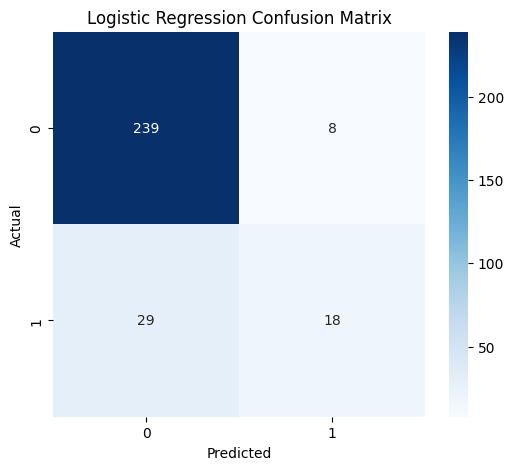

In [45]:
cm = confusion_matrix(
    y_test,
    y_pred_log
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [46]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [47]:
y_pred_rf = rf_model.predict(X_test)

In [48]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

Accuracy: 0.8367346938775511


In [49]:
print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_rf
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_rf
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred_rf
    )
)

Precision: 0.46153846153846156
Recall: 0.1276595744680851
F1 Score: 0.2


In [50]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.46      0.13      0.20        47

    accuracy                           0.84       294
   macro avg       0.66      0.55      0.55       294
weighted avg       0.79      0.84      0.80       294



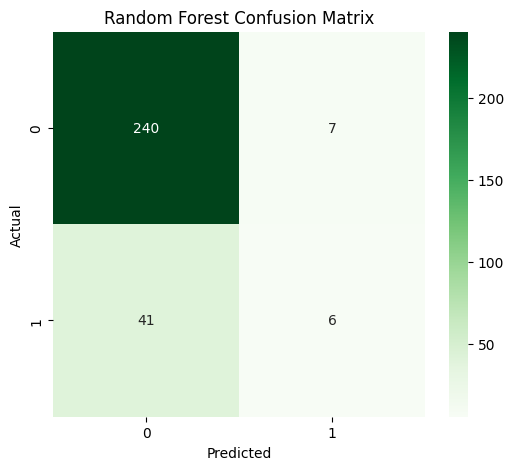

In [51]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [52]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(
            y_test,
            y_pred_log
        ),

        accuracy_score(
            y_test,
            y_pred_rf
        )
    ],

    "F1 Score": [
        f1_score(
            y_test,
            y_pred_log
        ),

        f1_score(
            y_test,
            y_pred_rf
        )
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.874150,0.493151
1,Random Forest,0.836735,0.200000


In [53]:
results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,F1 Score
0,Logistic Regression,0.874150,0.493151
1,Random Forest,0.836735,0.200000


In [54]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance":
    rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
15,MonthlyIncome,0.077536
0,Age,0.069066
23,TotalWorkingYears,0.063224
2,DailyRate,0.056067
9,HourlyRate,0.052921
16,MonthlyRate,0.050547
4,DistanceFromHome,0.048588
26,YearsAtCompany,0.042428
18,OverTime,0.040214
17,NumCompaniesWorked,0.037178


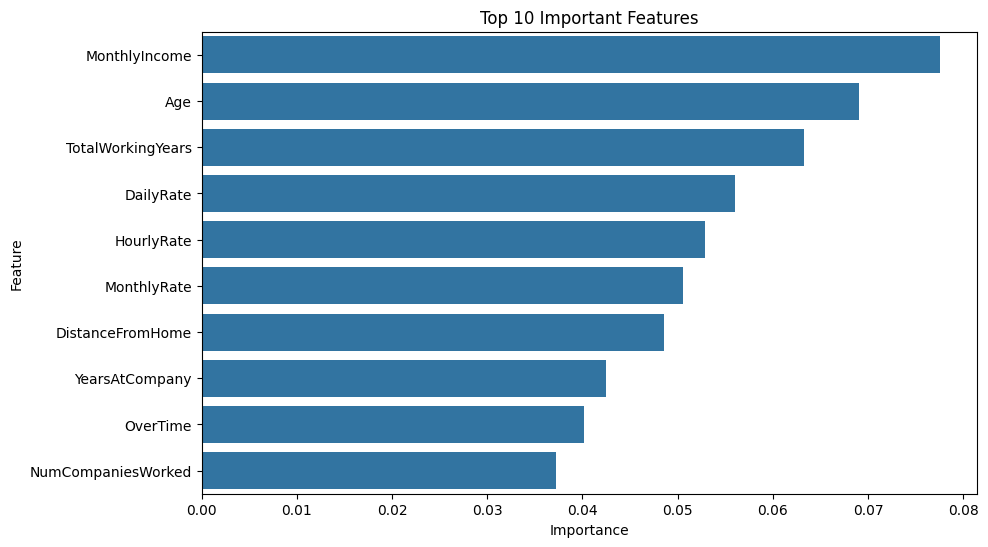

In [55]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [56]:
import joblib

joblib.dump(rf_model, 'attrition_model.pkl')

['attrition_model.pkl']

In [57]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [58]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in cat_cols:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col])
    encoders[col] = encoder

In [59]:
joblib.dump(encoders, 'encoders.pkl')

['encoders.pkl']

In [60]:
import os
os.listdir()

['.config',
 'attrition_model.pkl',
 'encoders.pkl',
 'WA_Fn-UseC_-HR-Employee-Attrition.csv',
 'scaler.pkl',
 'sample_data']

In [63]:
from google.colab import files

files.download('attrition_model.pkl')
files.download('scaler.pkl')
files.download('encoders.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
import joblib

joblib.dump(log_model, 'attrition_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoders, 'encoders.pkl')

['encoders.pkl']

In [65]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [66]:
import joblib

joblib.dump(log_model, 'attrition_model.pkl')

['attrition_model.pkl']

In [67]:
import os
os.listdir()

['.config',
 'attrition_model.pkl',
 'encoders.pkl',
 'WA_Fn-UseC_-HR-Employee-Attrition.csv',
 'scaler.pkl',
 'sample_data']

In [68]:
from google.colab import files
files.download('attrition_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
type(log_model)

sklearn.linear_model._logistic.LogisticRegression

In [70]:
X.columns.tolist()

['Age',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']